1. Exploratory Data Analysis.

In [1]:
import pandas as pd #for dataframes
import matplotlib.pyplot as plt #for visualization
import seaborn as sns #

In [2]:
df = pd.read_csv("Churn_Modelling.csv")

In [3]:
# printing the shape of the dataframe
print(df.shape)

(10000, 14)


In [4]:
#printing the five first rows
print(df.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age   
0          1    15634602  Hargrave          619    France  Female   42  \
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember   
0       2       0.00              1          1               1  \
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [5]:
# print the data type of each feature
print(df.dtypes)

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [6]:
#check for missing values
print(df.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


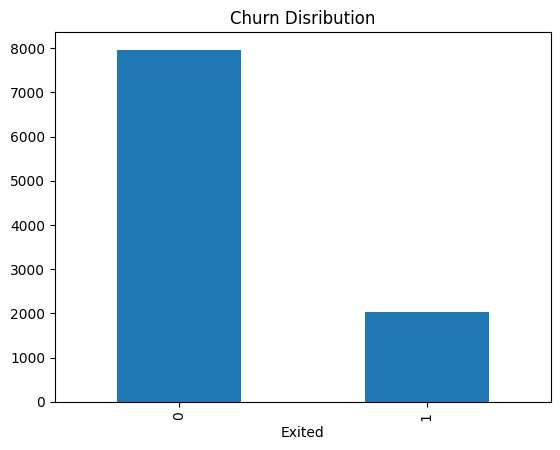

In [7]:
# Check for class inbalance
print(df["Exited"].value_counts(normalize=True))
df["Exited"].value_counts().plot(kind="bar")
plt.title("Churn Disribution")
plt.show()

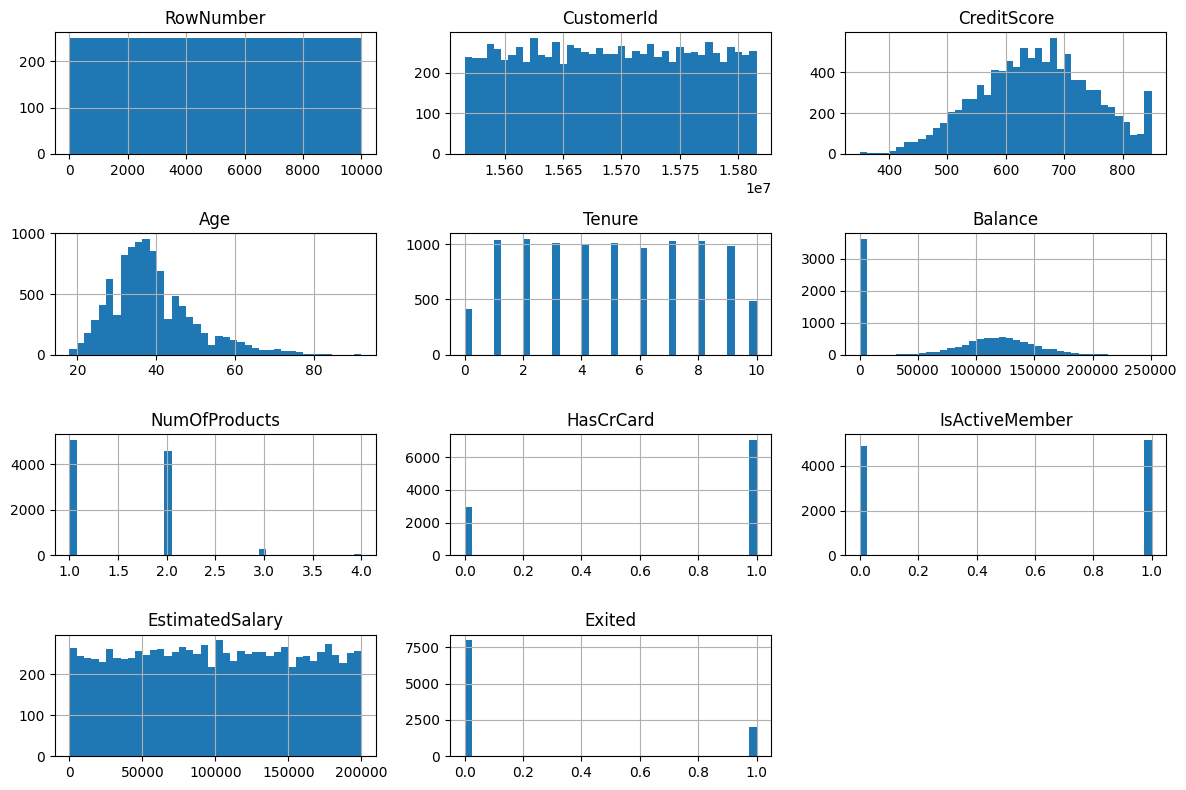

In [8]:
#numerical feature distribution
df.hist(figsize = (12, 8), bins = 40)
plt.tight_layout()
plt.show()

In [9]:
for col in ["Geography", "Gender", "NumOfProducts", "HasCrCard", "IsActiveMember"]:
    churn_rate = df.groupby(col)["Exited"].mean()
    print(churn_rate)

Geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64
Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64
NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64
HasCrCard
0    0.208149
1    0.201843
Name: Exited, dtype: float64
IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64


In [10]:
(df["NumOfProducts"] == 4).value_counts()

NumOfProducts
False    9940
True       60
Name: count, dtype: int64

2. Data Preprocessing

In [11]:
# dropping unnecessary columns
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

In [12]:
# Encode categorical columns
df = pd.get_dummies(df, columns = ["Geography", "Gender"], drop_first = True)

In [13]:
# splitting X and Y
X = df.drop(columns = ["Exited"])
y = df["Exited"]

In [14]:
# Train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [15]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(8000, 11) (2000, 11)
(8000,) (2000,)


In [16]:
!pip install xgboost 

In [22]:
# Training the XGBoost model

from xgboost import XGBClassifier

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale = neg / pos
print(scale)

model = XGBClassifier(n_estimators = 100, learning_rate = 0.1, max_depth = 4, scale_pos_weight = scale, eval_metric = "auc", random_state = 42)

model.fit(X_train, y_train, eval_set = [(X_test, y_test)], verbose = 10)

3.9079754601226995
[0]	validation_0-auc:0.80868


[10]	validation_0-auc:0.85110
[20]	validation_0-auc:0.86009
[30]	validation_0-auc:0.86540
[40]	validation_0-auc:0.86811
[50]	validation_0-auc:0.86971
[60]	validation_0-auc:0.87082
[70]	validation_0-auc:0.87107
[80]	validation_0-auc:0.87205
[90]	validation_0-auc:0.87301
[99]	validation_0-auc:0.87307


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)